In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [1]:
SR = 10e6  # V/s (10 V/us)
Vpp = 20.0
f_max_tri = SR/(2*Vpp)
print("f_max_tri (Hz) =", f_max_tri)

f = f_max_tri
Vp_seno = SR/(2*3.141592653589793*f)
print("Vp_max seno (V) =", Vp_seno)
print("Vpp_max seno (V) =", 2*Vp_seno)


f_max_tri (Hz) = 250000.0
Vp_max seno (V) = 6.366197723675814
Vpp_max seno (V) = 12.732395447351628


0.0 1.0 0.0
0.5 0.8944271909999159 -0.9691001300805644
1.0 0.7071067811865475 -3.0102999566398125
10.0 0.09950371902099892 -20.043213737826427
100.0 0.009999500037496875 -40.00043427276863


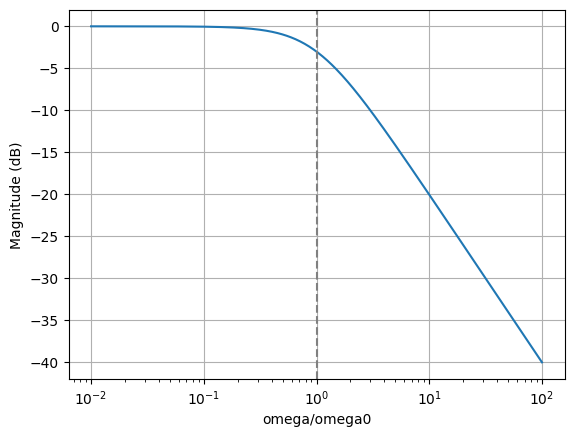

In [ ]:

w_ratio = np.array([0, 0.5, 1, 10, 100])
T = 1/np.sqrt(1 + w_ratio**2)
for r, t in zip(w_ratio, T):
    print(r, t, 20*np.log10(t))

# plot
w = np.logspace(-2, 2, 400)  # omega/omega0
T = 1/np.sqrt(1+w**2)
plt.semilogx(w, 20*np.log10(T))
plt.axvline(1, color='gray', linestyle='--')
plt.xlabel('omega/omega0'); plt.ylabel('Magnitude (dB)'); plt.grid(True)
plt.show()


In [2]:
# ---------- Parâmetros do opamp (modelo simples com um pólo) ----------
A0 = 1e5        # ganho DC do op-amp
f_pole = 1e6    # frequência do pólo (Hz) - ajuste conforme o opamp real
w_pole = 2*np.pi*f_pole

def A(jw):
    """Ganho do opamp como função de jw (modelo 1 pólo): A0 / (1 + jw/w_pole)"""
    return A0 / (1 + 1j * jw / w_pole)

# ---------- Exemplos de redes beta (realimentação) ----------
# Exemplo 1: Wien bridge (senoidal) - para referência (R, C) = (R, C)
def beta_wien(jw, R=10e3, C=15e-9):
    # Transfer function do divisor do Wien (da saída para o + do amplificador em oscilador típico)
    # Beta = Vfeedback/Vout para topologia clássica (aprox). Aqui usamos a expressão conhecida:
    # β(jw) = (1/3) * (jwRC) / (1 + jwRC - (jwRC)^2)  <-- forma simplificada (aprox), mas serve como exemplo
    sRC = 1j * jw * R * C
    # usar expressão padrão do network (forma educacional)
    return (1/3) * (sRC) / (1 + sRC - sRC**2)

# Exemplo 2: Phase-shift network (3 seções RC em cascata) - retorna β(jw) visto da saída para entrada inversora
def beta_phase_shift(jw, R=10e3, C=10e-9):
    s = 1j * jw
    # cada seção: H_i(s) = 1 / (1 + sRC) * (1 / (1 + 1/(sRC))) -- mas para simplicidade, modelamos as 3 seções standard:
    RC = R*C
    # Transfer function de uma seção simplificada:
    H1 = 1/(1 + s*RC)  # aproximação
    # beta total (aprox): saída depois das 3 seções em relação à saída original (normalmente pequena)
    return H1**3

In [3]:

# ---------- Função genérica que testa Barkhausen ----------
def testa_barkhausen(beta_func, A_func=A, fmin=1, fmax=1e6, points=10000, **beta_kwargs):
    freqs = np.logspace(np.log10(fmin), np.log10(fmax), points)
    jw = 2 * np.pi * freqs
    L = A_func(jw) * beta_func(jw, **beta_kwargs)

    mag = np.abs(L)
    phase = np.angle(L, deg=True)  # em graus

    # Procurar cruzamentos de fase por 0 deg (ajuste para faixa -180..180)
    # Normalizamos phase para -180..180
    phase_norm = (phase + 180) % 360 - 180

    # Encontrar pontos onde phase passa por 0 (procura sinal de mudança)
    crossings = []
    for i in range(len(freqs)-1):
        if phase_norm[i] == 0 or phase_norm[i+1] == 0:
            idx = i
            crossings.append(idx)
        elif phase_norm[i] * phase_norm[i+1] < 0:
            # há cruzamento
            # interpolação linear aproximada
            f_cross = freqs[i] - phase_norm[i] * (freqs[i+1]-freqs[i])/(phase_norm[i+1]-phase_norm[i])
            # magnitude aproximada em f_cross (interpolação log)
            mag_cross = np.interp(np.log10(f_cross), np.log10(freqs), mag)
            crossings.append((f_cross, mag_cross))
    # também aceitar pontos próximos a +360 ou -360:
    # (isso já está coberto pela normalização)

    # Colete resultados detalhados
    results = []
    for c in crossings:
        if isinstance(c, tuple):
            f_cross, mag_cross = c
        else:
            idx = c
            f_cross = freqs[idx]
            mag_cross = mag[idx]
        results.append({'f': f_cross, 'mag': mag_cross})

    return {
        'freqs': freqs,
        'mag': mag,
        'phase': phase_norm,
        'crossings': results
    }


Encontrados cruzamentos de fase (freq [Hz], |L|):
  Nenhum cruzamento de fase próximo de 0° encontrado no intervalo verificado.


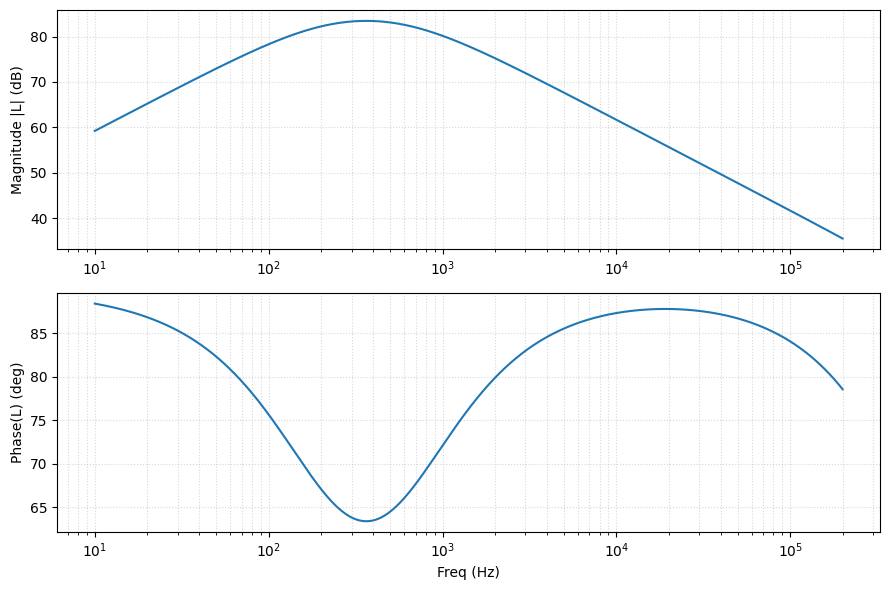

In [4]:
if __name__ == "__main__":
    # ajuste os parâmetros abaixo com os valores reais do seu circuito
    # Exemplo usando Wien com R=11.2k, C=39n (valores parecidos com a imagem que você enviou)
    R_example = 11.2e3
    C_example = 39e-9

    out = testa_barkhausen(beta_wien, A_func=A, fmin=10, fmax=200e3, points=20000, R=R_example, C=C_example)

    print("Encontrados cruzamentos de fase (freq [Hz], |L|):")
    if not out['crossings']:
        print("  Nenhum cruzamento de fase próximo de 0° encontrado no intervalo verificado.")
    else:
        for c in out['crossings']:
            print(f"  {c['f']:.2f} Hz, |L| = {c['mag']:.4f} (>=1 ? {'SIM' if c['mag']>=1 else 'NÃO'})")

    # Plot resumo
    freqs = out['freqs']
    mag = out['mag']
    phase = out['phase']

    plt.figure(figsize=(9,6))
    plt.subplot(2,1,1)
    plt.semilogx(freqs, 20*np.log10(mag))
    plt.ylabel('Magnitude |L| (dB)')
    plt.grid(True, which='both', ls=':', alpha=0.5)

    plt.subplot(2,1,2)
    plt.semilogx(freqs, phase)
    plt.ylabel('Phase(L) (deg)')
    plt.xlabel('Freq (Hz)')
    plt.grid(True, which='both', ls=':', alpha=0.5)

    plt.tight_layout()
    plt.show()